# 🚀 Huấn luyện và Đánh giá Mô hình Dual-Model BTCUSDT 15m (v4.1)

Notebook này hướng dẫn quy trình toàn diện từ chuẩn bị dữ liệu, huấn luyện mô hình kết hợp (**PivotTransformer** + **CandleLSTM**), chạy kiểm định **Walk-Forward Validation**, phân tích **Edge Calibration**, và backtest ngoài mẫu (Out-Of-Sample) kèm so sánh với các baseline thống kê (Monte Carlo & Logistic Regression).

In [1]:
# 1. Import các thư viện cần thiết
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Import các thành phần từ pipeline model.py
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'model_training' / 'model.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'model_training' / 'model.py').exists():
    raise FileNotFoundError('Cannot find model_training/model.py; open this notebook inside BTC_PIPELINE.')
sys.path.insert(0, str(PROJECT_ROOT))

from model_training.model import (
    Config,
    load_candles,
    find_confirmed_pivots,
    prepare_examples,
    make_market,
    run_pipeline,
    run_walk_forward,
    tune_thresholds,
    run_backtest,
    fit_final_models,
    predict_ids,
    edge_calibration,
    bootstrap_mean_ci,
    random_entry_baseline,
    year_bounds,
    resolve_device
)

# Thiết lập hiển thị đồ thị và cấu hình PyTorch
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

device = resolve_device('auto')
print(f"Thiết bị tính toán khả dụng: {device}")

Thiết bị tính toán khả dụng: cuda


## 2. Cấu hình Pipeline (Config)

Bạn có thể tùy chỉnh các siêu tham số tại đây (đường dẫn dữ liệu, các năm walk-forward, năm backtest kiểm định, số epoch, v.v.).

In [2]:
cfg = Config(
    csv_path=str(PROJECT_ROOT / "historical_data" / "BTCUSDT_15m_all.csv"),
    output_dir=str(PROJECT_ROOT / "artifacts" / "15m_dual_models"),
    fold_years=(2023, 2024, 2025),
    backtest_year=2026,
    epochs=8,
    batch_size=512,
    learning_rate=3e-4,
    hidden_size=64,
    dropout=0.15,
    calibrate_temperature=True,    # Bật hiệu chỉnh xác suất (Temperature Scaling)
    funding_bps_per_8h=0.5,        # Chi phí Funding ước tính (0.005% / 8h)
    fee_bps=4.0,                   # Phí taker: 0.04%
    slippage_bps=2.0,              # Trượt giá: 0.02%
    tune_thresholds=True,
    run_baselines=True,
    random_baseline_sims=300,
    device="auto"
)

print("Cấu hình đã khởi tạo:")
print(f"- Chi phí vòng lặp (Round-trip cost): {cfg.cost * 100:.3f}%")
print(f"- Giới hạn Barrier b: [{cfg.min_barrier * 100:.2f}%, {cfg.max_barrier * 100:.2f}%]")
print(f"- Cửa sổ giữ lệnh tối đa (H): {cfg.barrier_horizon} nến ({cfg.barrier_horizon * 15 / 60:.1f} giờ)")

Cấu hình đã khởi tạo:
- Chi phí vòng lặp (Round-trip cost): 0.120%
- Giới hạn Barrier b: [0.70%, 3.00%]
- Cửa sổ giữ lệnh tối đa (H): 24 nến (6.0 giờ)


## 3. Khám phá & Tiền xử lý Dữ liệu (EDA & Feature Previews)

Kiểm tra nến, tính toán các điểm đảo chiều ZigZag (causal) và phân bố nhãn Triple-Barrier.

Tổng số nến: 219,350
Tổng số ZigZag pivots xác nhận: 46,456
Số mẫu dữ liệu hợp lệ: 218,318


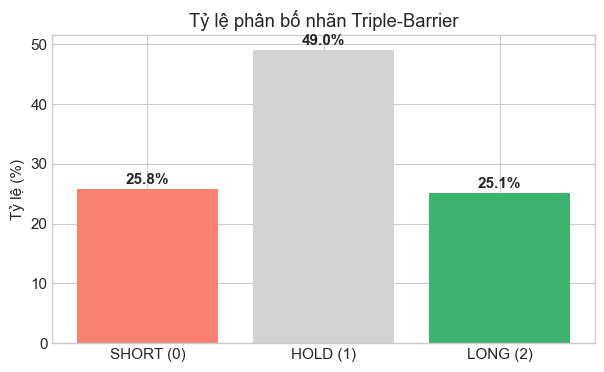

In [3]:
if Path(cfg.csv_path).exists():
    df = load_candles(cfg.csv_path, cfg.bar_minutes)
    pivots = find_confirmed_pivots(df, cfg.pivot_reversal)
    data = prepare_examples(df, pivots, cfg)
    mkt = make_market(df)
    
    print(f"Tổng số nến: {len(df):,}")
    print(f"Tổng số ZigZag pivots xác nhận: {len(pivots):,}")
    print(f"Số mẫu dữ liệu hợp lệ: {len(data.decision_idx):,}")
    
    # Phân bố nhãn
    counts = np.bincount(data.y, minlength=3)
    labels = ["SHORT (0)", "HOLD (1)", "LONG (2)"]
    plt.figure(figsize=(7, 4))
    plt.bar(labels, counts / len(data.y) * 100, color=['salmon', 'lightgray', 'mediumseagreen'])
    plt.title("Tỷ lệ phân bố nhãn Triple-Barrier")
    plt.ylabel("Tỷ lệ (%)")
    for i, v in enumerate(counts):
        plt.text(i, v / len(data.y) * 100 + 0.8, f"{v / len(data.y) * 100:.1f}%", ha='center', fontweight='bold')
    plt.show()
else:
    print(f"Chưa tìm thấy tệp CSV tại '{cfg.csv_path}'. Hãy chuẩn bị dữ liệu lịch sử trước khi chạy.")

## 4. Chạy Toàn bộ Pipeline Huấn luyện & Kiểm định (Walk-Forward)

Hàm `run_pipeline(cfg)` sẽ tự động thực hiện:
1. Huấn luyện **Walk-forward** theo từng năm (`fold_years`), tính toán Log Loss Skill, Balanced Accuracy so với Logistic Regression và Prior.
2. Tối ưu ngưỡng biên độ (`min_edge`) và chế độ tín hiệu (`signal_mode`) chỉ dựa trên dữ liệu các fold trong quá khứ.
3. Huấn luyện mô hình cuối cùng trên toàn bộ dữ liệu trước năm test (`backtest_year`).
4. Đánh giá Backtest ngoài mẫu (Out-Of-Sample) trên năm `backtest_year` kèm Monte Carlo random entries và Bootstrap CI.

In [4]:
if Path(cfg.csv_path).exists():
    print("Bắt đầu huấn luyện pipeline...")
    results = run_pipeline(cfg)
    print("Hoàn tất huấn luyện và lưu artifacts thành công!")
else:
    print("Vui lòng cung cấp dữ liệu CSV để khởi chạy pipeline.")

Bắt đầu huấn luyện pipeline...
Hoàn tất huấn luyện và lưu artifacts thành công!


## 5. Phân tích Chi tiết Kết quả Walk-Forward

Bảng tổng hợp chỉ số hiệu suất của các mô hình trên từng năm kiểm định độc lập.

--- BẢNG CHỈ SỐ WALK-FORWARD ---


,fold,model,samples,log_loss,prior_log_loss,log_loss_skill,accuracy,balanced_accuracy,dir_accuracy,majority_accuracy,logreg_log_loss,logreg_dir_accuracy
0,2023,pivot_transformer,35016,0.9791,1.0290,0.0486,0.5192,0.4215,0.5366,0.5403,1.0542,0.5096
1,2023,candle_lstm,35016,0.9792,1.0290,0.0484,0.5290,0.4176,0.5410,0.5403,0.9869,0.5382
2,2023,ensemble,35016,0.9644,1.0290,0.0628,0.5310,0.4224,0.5402,0.5403,NaN,NaN
3,2024,pivot_transformer,35112,0.9713,1.0494,0.0744,0.5313,0.4368,0.5375,0.4864,0.9960,0.5302
4,2024,candle_lstm,35112,0.9578,1.0494,0.0873,0.5333,0.4289,0.5380,0.4864,0.9904,0.5354
5,2024,ensemble,35112,0.9578,1.0494,0.0873,0.5381,0.4368,0.5431,0.4864,NaN,NaN
6,2025,pivot_transformer,35016,0.9452,1.0258,0.0786,0.5582,0.4428,0.5335,0.5245,0.9820,0.5404
7,2025,candle_lstm,35016,0.9244,1.0258,0.0988,0.5608,0.4486,0.5311,0.5245,0.9651,0.5258
8,2025,ensemble,35016,0.9247,1.0258,0.0985,0.5643,0.4481,0.5392,0.5245,NaN,NaN


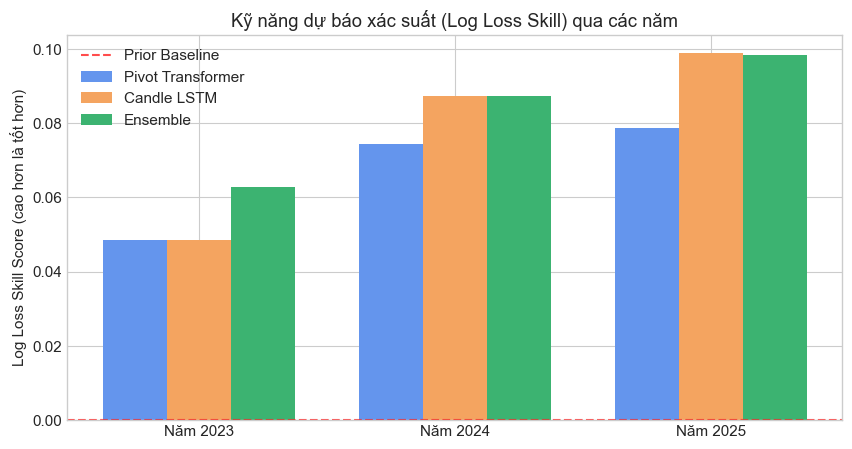

In [5]:
if 'results' in locals():
    wf_table = results["folds"]
    print("--- BẢNG CHỈ SỐ WALK-FORWARD ---")
    display(wf_table.round(4))
    
    # Biểu đồ Log Loss Skill so sánh giữa các mô hình
    pivot_skill = wf_table[wf_table["model"] == "pivot_transformer"]["log_loss_skill"].to_numpy()
    lstm_skill = wf_table[wf_table["model"] == "candle_lstm"]["log_loss_skill"].to_numpy()
    ens_skill = wf_table[wf_table["model"] == "ensemble"]["log_loss_skill"].to_numpy()
    years = wf_table[wf_table["model"] == "ensemble"]["fold"].to_numpy()
    
    x = np.arange(len(years))
    width = 0.25
    plt.figure(figsize=(10, 5))
    plt.bar(x - width, pivot_skill, width, label='Pivot Transformer', color='cornflowerblue')
    plt.bar(x, lstm_skill, width, label='Candle LSTM', color='sandybrown')
    plt.bar(x + width, ens_skill, width, label='Ensemble', color='mediumseagreen')
    plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Prior Baseline')
    plt.xticks(x, [f"Năm {y}" for y in years])
    plt.ylabel("Log Loss Skill Score (cao hơn là tốt hơn)")
    plt.title("Kỹ năng dự báo xác suất (Log Loss Skill) qua các năm")
    plt.legend()
    plt.show()

## 6. Phân tích Độ Tin Cậy & Hiệu Chuẩn Xác Suất (Edge Calibration)

Kiểm tra xem khi mô hình dự báo độ chênh xác suất cao $P(\text{LONG}) - P(\text{SHORT})$, tần suất thắng thực tế có tỷ lệ thuận hay không.

--- BẢNG HIỆU CHUẨN XÁC SUẤT (EDGE CALIBRATION) ---


,bin,samples,predicted_edge,realised_edge,hold_rate
0,0,5273,-0.0807,-0.0457,0.4472
1,1,5273,-0.0206,-0.0195,0.5450
2,2,5274,0.0063,-0.0195,0.6088
3,3,5272,0.0363,-0.0425,0.5281
4,4,5274,0.0994,0.0417,0.4308


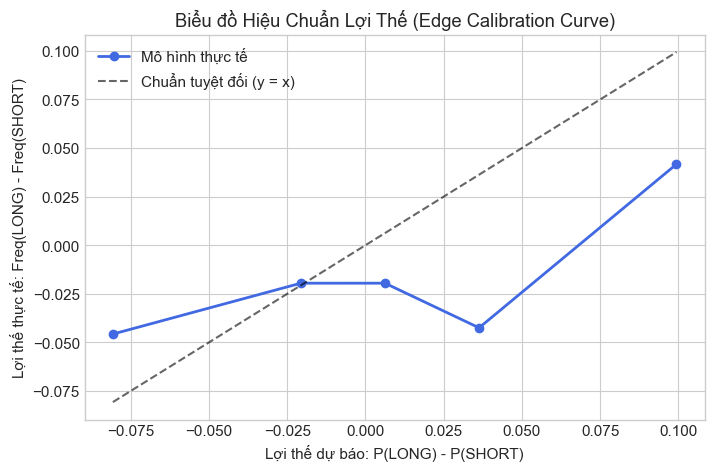

In [6]:
if 'results' in locals() and 'data' in locals():
    # Tải lại dự báo của fold gần nhất
    last_fold = cfg.fold_years[-1]
    out_dir = Path(cfg.output_dir)
    
    # Tính toán bảng calibration
    fitted = fit_final_models(data, cfg)
    start, end = year_bounds(cfg.backtest_year)
    test_ids = np.flatnonzero((data.timestamp_ns >= start) & (data.timestamp_ns < end))
    preds = predict_ids(fitted, data, test_ids, cfg)
    
    calib_df = edge_calibration(data, preds, cfg, bins=5)
    print("--- BẢNG HIỆU CHUẨN XÁC SUẤT (EDGE CALIBRATION) ---")
    display(calib_df.round(4))
    
    # Biểu đồ Calibration
    plt.figure(figsize=(8, 5))
    plt.plot(calib_df["predicted_edge"], calib_df["realised_edge"], marker='o', linewidth=2, color='royalblue', label='Mô hình thực tế')
    min_v, max_v = calib_df["predicted_edge"].min(), calib_df["predicted_edge"].max()
    plt.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.6, label='Chuẩn tuyệt đối (y = x)')
    plt.xlabel("Lợi thế dự báo: P(LONG) - P(SHORT)")
    plt.ylabel("Lợi thế thực tế: Freq(LONG) - Freq(SHORT)")
    plt.title("Biểu đồ Hiệu Chuẩn Lợi Thế (Edge Calibration Curve)")
    plt.legend()
    plt.show()

## 7. Phân tích Kết quả Backtest Ngoài Mẫu (Out-of-Sample Backtest)

Đánh giá chi tiết đường cong vốn (**Equity Curve**), tỷ lệ thắng, tỷ suất lợi nhuận, drawdown và phân phối PnL trên năm test.

--- TỔNG KẾT HIỆU SUẤT BACKTEST NĂM 2026 ---
strategy                 : unified_triple_barrier_v4_next_open
year                     : 2026
prediction_candles       : 26366
trades                   : 105
total_return             : -0.07913757863791226
win_rate                 : 0.4666666666666667
average_trade            : -0.0006932398565394257
profit_factor            : 0.8878545963827441
max_drawdown             : -0.1949995815334754
sharpe                   : -0.56825126514834
exposure                 : 0.05733232284956423
avg_barrier              : 0.015559451455268793
min_edge                 : 0.06
signal_mode              : agree
mean_trade_ci95          : [-0.0032576519210234176, 0.0018399437282882857]


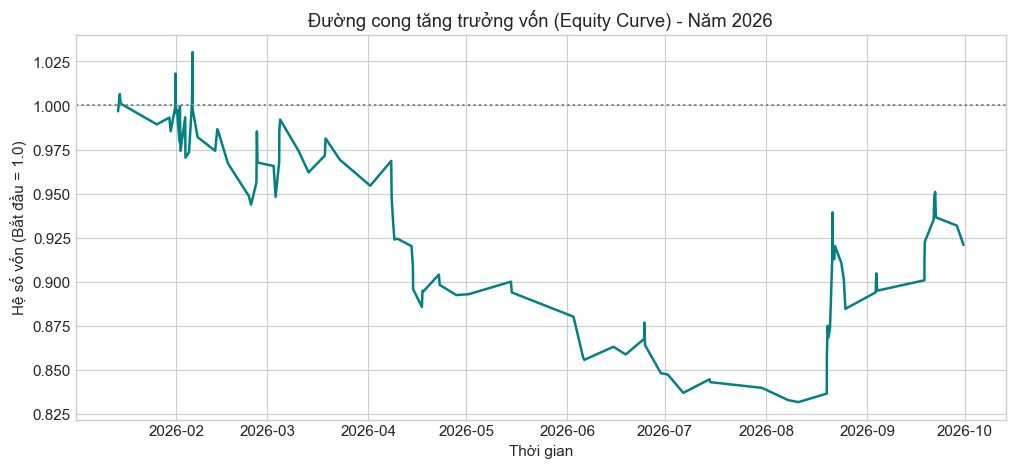

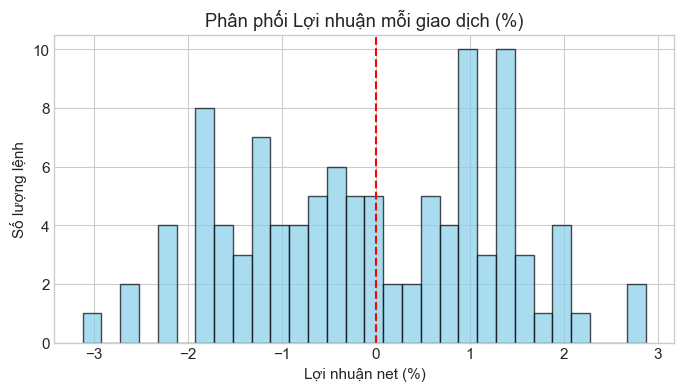

In [7]:
if 'results' in locals():
    summary = results["backtest"]
    print("--- TỔNG KẾT HIỆU SUẤT BACKTEST NĂM", cfg.backtest_year, "---")
    for k, v in summary.items():
        if k != "random_entry_baseline":
            print(f"{k:25s}: {v}")
            
    # Tải danh sách giao dịch chi tiết từ artifacts
    trades_file = Path(cfg.output_dir) / f"backtest_{cfg.backtest_year}_trades.csv"
    if trades_file.exists():
        trades_df = pd.read_csv(trades_file)
        
        # Vẽ đường cong vốn (Equity Curve)
        plt.figure(figsize=(12, 5))
        plt.plot(pd.to_datetime(trades_df["exit_time"]), trades_df["equity"], color='teal', linewidth=1.8)
        plt.title(f"Đường cong tăng trưởng vốn (Equity Curve) - Năm {cfg.backtest_year}")
        plt.xlabel("Thời gian")
        plt.ylabel("Hệ số vốn (Bắt đầu = 1.0)")
        plt.axhline(1.0, color='gray', linestyle=':')
        plt.show()
        
        # Phân phối lợi nhuận các lệnh
        plt.figure(figsize=(8, 4))
        plt.hist(trades_df["return"] * 100, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--')
        plt.title("Phân phối Lợi nhuận mỗi giao dịch (%)")
        plt.xlabel("Lợi nhuận net (%)")
        plt.ylabel("Số lượng lệnh")
        plt.show()

## 8. So sánh với Kiểm định Ngẫu nhiên (Monte Carlo Baseline)

Kiểm tra xem lợi nhuận của chiến lược có thực sự đến từ năng lực chọn điểm vào lệnh của mô hình, hay chỉ là do biến động ngẫu nhiên của thị trường.

In [8]:
if 'results' in locals() and "random_entry_baseline" in results["backtest"]:
    rand_res = results["backtest"]["random_entry_baseline"]
    if rand_res:
        print("--- KẾT QUẢ MONTE CARLO RANDOM ENTRY BENCHMARK ---")
        print(f"- Số lần mô phỏng: {rand_res['simulations']}")
        print(f"- Lợi nhuận kỳ vọng ngẫu nhiên (Mean): {rand_res['mean_total_return'] * 100:.2f}%")
        print(f"- Khoảng phân vị 5% - 95%: [{rand_res['p05_total_return'] * 100:.2f}%, {rand_res['p95_total_return'] * 100:.2f}%]")
        print(f"- Vị thế phần trăm của mô hình (Percentile): {rand_res['model_percentile'] * 100:.2f}%")
        
        ci = results["backtest"].get("mean_trade_ci95")
        if ci:
            print(f"- Khoảng tin cậy Bootstrap 95% lợi nhuận trung bình/lệnh: [{ci[0]*100:.3f}%, {ci[1]*100:.3f}%]")

--- KẾT QUẢ MONTE CARLO RANDOM ENTRY BENCHMARK ---
- Số lần mô phỏng: 300
- Lợi nhuận kỳ vọng ngẫu nhiên (Mean): -12.75%
- Khoảng phân vị 5% - 95%: [-24.17%, 0.22%]
- Vị thế phần trăm của mô hình (Percentile): 76.00%
- Khoảng tin cậy Bootstrap 95% lợi nhuận trung bình/lệnh: [-0.326%, 0.184%]
